# Pipeline Stage 2 — Slope & Curvature Calculation

This notebook is the **calculation half** of the v7 pipeline. It reads
already-filtered ground points from a `.bin` file (produced by
`filter_ground_points.ipynb`) and computes ground slope and curvature with
**three different methods**, so they can be compared apples-to-apples.

| Method | Per-bin operation | Curvature comes from |
|---|---|---|
| **PCA**             | covariance → eigenvectors    | second derivative of slope (`-n_x / n_z`) |
| **RANSAC**          | random samples → consensus plane | second derivative of slope (`-n_x / n_z`) |
| **Height-derivative** | median z per bin (no plane fit) | `np.gradient` applied twice to z |

The first two share *everything* downstream of the plane fit — what differs is
how the local plane is computed. The third never fits a plane at all: it goes
straight from heights to numerical derivatives. That's the cleanest of all
contrasts for the BEP report — three methods that agree where they should and
disagree where it's *interesting*.

### Analogy — three ways to ask "is the road curving?"

* **PCA.** Take a handful of pebbles in a 0.5 m bin. Fit the flattest plane
  through them. Read the plane's tilt; that's your local slope. Repeat along
  the road, then check how the slope is *changing* — that's the curvature.
* **RANSAC.** Same idea, but instead of using *all* the pebbles, randomly grab
  three at a time, draw a plane through them, count how many of the rest sit
  near it, and take the plane that wins the most votes. Robust to weird
  pebbles; otherwise the same downstream maths.
* **Height-derivative.** Don't bother with planes at all. Take the *median*
  pebble height in each bin, smooth that 1-D height profile, then differentiate
  it twice. This is the textbook calculus definition of curvature applied
  directly to $z(x)$.

### About the "ironic" comparison

You'll notice that for the **forward 1-D profile** all three methods boil down
to the same numerical derivative of *something* with respect to $x$. The
genuine algorithmic differences live in **how each method estimates the local
slope** at each bin — the per-bin step. PCA uses every point; RANSAC uses the
consensus plane; height-derivative uses only the median height. After that,
the smoothing and differentiation are identical, which is *exactly* what you
want for an A/B/C comparison: every pipeline stage downstream of the plane fit
is held fixed.

In [ ]:
# Run once if you don't have these:
# !pip install numpy matplotlib

import os
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)


# ==========================================================
# INPUT  --  point this at the .bin produced by Notebook 1
# ----------------------------------------------------------
# Default = Patchwork++ only output. Change the suffix to
# read a different filtration:
#   "_pw"       -> Patchwork++ only
#   "_pw_gle"   -> Patchwork++ + eigenvalue/flatness post-filter
# ==========================================================
GROUND_BIN_DIR  = r"C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points"
INPUT_BIN_NAME  = "ground_points.bin"   # change to compare filters
INPUT_BIN_PATH  = r"C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\ground_points.bin"
#INPUT_BIN_PATH  = os.path.join(GROUND_BIN_DIR, INPUT_BIN_NAME)



# ==========================================================
# REGION OF INTEREST
# ----------------------------------------------------------
# Same convention as Notebook 1 -- a strip in front of the
# bike where forward curvature actually matters.
# ==========================================================
ROI_X_RANGE = (-5.0, 20.0)   # forward / backward [m]
ROI_Y_RANGE = (-1.0,  1.0)   # left / right       [m]
GRID_Y_RANGE   = (-1,  1)   # for the 2-D heatmap (wider view)

# ==========================================================
# SHARED PROFILE PARAMETERS
# ----------------------------------------------------------
# Used by all three methods so the comparison stays apples-to-apples.
# ==========================================================
PROFILE_BIN_SIZE      = 0.5    # [m] forward bin width
PROFILE_MIN_PTS       = 15      # min points to attempt a plane fit
PROFILE_MEDIAN_WINDOW = 5      # outlier suppression
PROFILE_SMOOTH_WINDOW = 7      # smoothing after the median filter


# ==========================================================
# RANSAC parameters
# ----------------------------------------------------------
# Kept loose enough that on already-filtered ground RANSAC and PCA
# agree to within a few percent on the slope field.
# ==========================================================
RANSAC_N_ITER       = 50       # number of random plane proposals per bin
RANSAC_DIST_THRESH  = 0.05     # [m] inlier band thickness
RANSAC_MIN_INLIERS  = 8        # below this -> fall back to PCA on the bin
RANSAC_SEED         = 0        # set to None for non-deterministic runs


# ==========================================================
# 2-D Cartesian grid (heatmap visualisation)
# ==========================================================
GRID_CELL_SIZE        = 1.0    # [m]
GRID_MIN_PTS_PER_CELL = 12

## 1. Load the filtered ground points

These came out of **Notebook 1**. The format is nuScenes-style
`(N, 5)` `float32` — `[x, y, z, intensity, ring]` — but only XYZ matter
(intensity and ring are zero-padded).

> **If you get `FileNotFoundError`:** run `filter_ground_points.ipynb` first
> with `EXPORT_GROUND = True`, or change `INPUT_BIN_NAME` above to whatever
> file is actually in `GROUND_BIN_DIR`.

Loaded ground points from:
  C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\ground_points.bin
  count:   56,100
  X range: [-46.9, 45.1] m
  Y range: [-45.2, 48.3] m
  Z range: [-1.6, 11.0] m


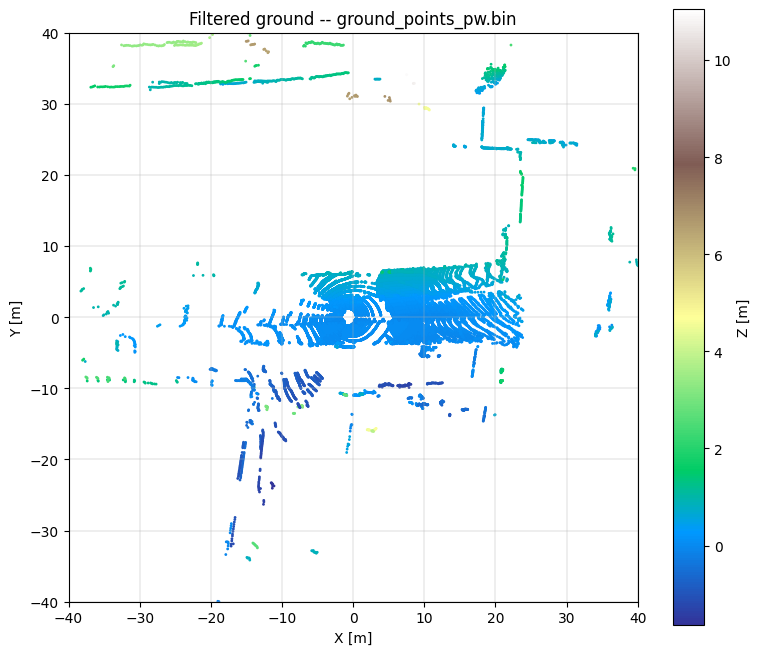

In [50]:
def load_nuscenes_bin(path):
    """Load (N, 3) XYZ from a nuScenes-format .bin file."""
    pts = np.fromfile(path, dtype=np.float32).reshape(-1, 5)
    return pts[:, :3].astype(np.float64)


ground = load_nuscenes_bin(INPUT_BIN_PATH)
print(f"Loaded ground points from:\n  {INPUT_BIN_PATH}")
print(f"  count:   {len(ground):,}")
print(f"  X range: [{ground[:,0].min():.1f}, {ground[:,0].max():.1f}] m")
print(f"  Y range: [{ground[:,1].min():.1f}, {ground[:,1].max():.1f}] m")
print(f"  Z range: [{ground[:,2].min():.1f}, {ground[:,2].max():.1f}] m")


# Quick BEV
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(ground[:, 0], ground[:, 1], c=ground[:, 2],
                s=1, cmap="terrain")
plt.colorbar(sc, ax=ax, label="Z [m]", shrink=0.8)
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
ax.set_xlim(-40, 40); ax.set_ylim(-40, 40)
ax.set_aspect("equal"); ax.grid(True, lw=0.3)
ax.set_title(f"Filtered ground -- {INPUT_BIN_NAME}")
plt.tight_layout(); plt.show()

## 2. Shared utilities — smoothing & 1-D profile harness

Two helpers used by **all three methods** so the only thing that genuinely differs
between PCA / RANSAC / height-derivative is the *plane-fit / slope-estimation* step:

* `_median_filter` then `_moving_average` — a two-stage smoother. Median first
  (kills isolated spikes), mean second (smooths what survives). Doing it the
  other way round just spreads the bad sample over its neighbours.

* `compute_road_profile_from_normals(...)` — the v7 function that crops a
  forward strip, bins by `x`, calls a user-supplied `fit_normal(bin_pts)` per
  bin to get a unit normal, reads `dz/dx = -n_x / n_z`, smooths, and
  differentiates once to get $\kappa$. Both PCA and RANSAC plug into this.

The height-derivative method takes a separate, parallel function
(`compute_road_profile_from_heights`) since it never produces a normal — it just
goes from heights straight to derivatives.

In [75]:
# ============================================================
# Smoothing helpers
# ============================================================
def _median_filter(y, window):
    """Per-sample median over `window` neighbours (reflective padding)."""
    if window <= 1:
        return y.copy()
    pad = window // 2
    y_pad = np.pad(y, pad, mode="reflect")
    out = np.empty_like(y)
    for i in range(len(y)):
        out[i] = np.median(y_pad[i:i + window])
    return out


def _moving_average(y, window):
    """Reflective-padded moving average. Length-preserving."""
    if window <= 1:
        return y.copy()
    pad = window // 2
    y_pad = np.pad(y, pad, mode="reflect")
    kernel = np.ones(window) / window
    return np.convolve(y_pad, kernel, mode="valid")[:len(y)]


def _two_stage_smooth(y, median_window, smooth_window):
    """Median first (kills spikes), then moving average (smooths the rest)."""
    return _moving_average(_median_filter(y, median_window), smooth_window)

In [76]:
# ============================================================
# 1-D forward profile -- slope read DIRECTLY from a plane normal
# ============================================================
#
# Plane equation:  n_x * x + n_y * y + n_z * z + d = 0
# Solve for z:     z(x, y) = -(n_x*x + n_y*y + d) / n_z
# Forward slope:   dz/dx = -n_x / n_z         (signed; n_z > 0)
#
# Curvature is then ONE numerical derivative of the slope plus
# the Frenet correction:
#       kappa(x) = (d/dx)(dz/dx) / (1 + (dz/dx)^2)^(3/2)        [1/m]
#
# Sign convention with n_z > 0 enforced:
#       dz/dx > 0  -> uphill in +X
#       dz/dx < 0  -> downhill in +X
#       kappa < 0  -> hill crest (concave down)
#       kappa > 0  -> valley bottom (concave up)


def compute_road_profile_from_normals(ground_points,
                                      fit_normal,
                                      x_range=ROI_X_RANGE,
                                      y_half_width=abs(ROI_Y_RANGE[1]),
                                      bin_size=PROFILE_BIN_SIZE,
                                      min_pts=PROFILE_MIN_PTS,
                                      median_window=PROFILE_MEDIAN_WINDOW,
                                      smooth_window=PROFILE_SMOOTH_WINDOW,
                                      method_label="(unspecified)"):
    """Forward 1-D road profile. Plane fit per bin via `fit_normal(bin_pts)`."""
    # 1. crop forward strip
    m = ((ground_points[:, 0] >= x_range[0]) &
         (ground_points[:, 0] <= x_range[1]) &
         (np.abs(ground_points[:, 1]) <= y_half_width))
    pts = ground_points[m]
    if len(pts) < 10:
        print("Not enough ground points in the forward strip.")
        return None

    # 2. set up X bins
    x_edges   = np.arange(x_range[0], x_range[1] + bin_size, bin_size)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    n_bins = len(x_centers)

    # 3. per-bin: median z + signed slope from plane normal
    z_bin    = np.full(n_bins, np.nan)
    dzdx_bin = np.full(n_bins, np.nan)

    for i in range(n_bins):
        in_bin = (pts[:, 0] >= x_edges[i]) & (pts[:, 0] < x_edges[i + 1])
        bin_pts = pts[in_bin]
        if len(bin_pts) < min_pts:
            continue
        z_bin[i] = float(np.median(bin_pts[:, 2]))
        try:
            n = fit_normal(bin_pts)
            if abs(n[2]) > 1e-6:
                dzdx_bin[i] = -n[0] / n[2]
        except Exception:
            pass

    valid_z = ~np.isnan(z_bin)
    valid_s = ~np.isnan(dzdx_bin)
    if valid_z.sum() < 5 or valid_s.sum() < 5:
        print("Not enough populated bins for a profile.")
        return None

    # 4. fill NaN gaps so derivatives are defined everywhere
    z_filled    = np.interp(x_centers, x_centers[valid_z], z_bin[valid_z])
    dzdx_filled = np.interp(x_centers, x_centers[valid_s], dzdx_bin[valid_s])

    # 5. two-stage smoothing
    z_smooth    = _two_stage_smooth(z_filled,    median_window, smooth_window)
    dzdx_smooth = _two_stage_smooth(dzdx_filled, median_window, smooth_window)

    # 6. one differentiation -> second derivative
    d2zdx2 = np.gradient(dzdx_smooth, bin_size)

    # 7. signed Frenet curvature
    kappa = d2zdx2 / (1.0 + dzdx_smooth ** 2) ** 1.5

    return dict(
        x=x_centers,
        z=z_smooth,
        z_raw=z_bin,
        slope_deg=np.degrees(np.arctan(dzdx_smooth)),
        slope_raw_deg=np.degrees(np.arctan(dzdx_bin)),
        kappa=kappa,
        kappa_abs=np.abs(kappa),
        valid_z_mask=valid_z,
        valid_s_mask=valid_s,
        bin_size=bin_size,
        method=method_label,
    )

## 3. The three plane-fit / slope-estimation methods

### 3a. PCA per bin

PCA's smallest-eigenvalue eigenvector is the normal to the best least-squares
plane through the bin. Deterministic, fast, uses every point.

### 3b. RANSAC per bin

Pick 3 points, draw a plane, count how many of the rest fall within
`dist_thresh` metres of it; repeat `n_iter` times; keep the winner. Robust
to a few wild outliers (a bush stem, a stray pole base) but stochastic.
Tiny re-runs may flicker by < 1° in slope — that's the price of randomness.
We seed the RNG so this notebook is reproducible.

### 3c. Height-derivative — *no plane fit at all*

For each bin, take just the **median height** $\tilde{z}_i$ of the points in
the bin. Smooth $\tilde{z}(x)$. Then take `np.gradient` once to get
$dz/dx$ and a second time to get $d^2z/dx^2$. This is the textbook
`differentiate twice` approach — it amplifies noise quadratically (which is
why the smoothing window matters more here), and it never uses any
information about how the points within a bin are distributed in $z$
beyond their median.

Why bother? Because it's the **simplest possible curvature estimator** —
every more sophisticated method has to beat it. If PCA and RANSAC don't
clearly outperform height-derivative on a real terrain frame, they probably
aren't earning their complexity. That's a defensible BEP comparison.

In [77]:
# ============================================================
# Method 1: PCA per bin
# ============================================================
def fit_pca_normal(bin_pts):
    """PCA plane fit. Returns upward-pointing unit normal (3,)."""
    pts_c = bin_pts.astype(np.float64) - bin_pts.mean(axis=0)
    C = (pts_c.T @ pts_c) / max(len(pts_c) - 1, 1)
    eigvals, eigvecs = np.linalg.eigh(C)        # ascending
    n = eigvecs[:, 0]                            # smallest eigval -> normal
    if n[2] < 0:
        n = -n
    return n

In [78]:
def fit_ransac_normal(bin_pts,
                      n_iter=RANSAC_N_ITER,
                      dist_thresh=RANSAC_DIST_THRESH,
                      min_inliers=RANSAC_MIN_INLIERS,
                      rng=None):
    """RANSAC plane fit. Returns the normal of the 3-point plane
    that achieved the highest inlier consensus. No PCA refit.
    """
    rng = rng or _ransac_rng
    pts = bin_pts.astype(np.float64)
    n_pts = len(pts)
    if n_pts < 3:
        raise RuntimeError(f"RANSAC needs >=3 pts, got {n_pts}.")

    best_normal = None
    best_count  = -1

    for _ in range(n_iter):
        idx = rng.choice(n_pts, 3, replace=False)
        p0, p1, p2 = pts[idx]
        n_try = np.cross(p1 - p0, p2 - p0)
        norm = np.linalg.norm(n_try)
        if norm < 1e-9:
            continue
        n_try = n_try / norm
        if n_try[2] < 0:
            n_try = -n_try
        n_inliers = int((np.abs((pts - p0) @ n_try) < dist_thresh).sum())
        if n_inliers > best_count:
            best_count  = n_inliers
            best_normal = n_try

    if best_normal is None or best_count < min_inliers:
        raise RuntimeError(
            f"RANSAC failed: best consensus only {best_count} inliers "
            f"(need {min_inliers}, dist_thresh={dist_thresh} m, "
            f"n_iter={n_iter}, bin has {n_pts} pts)."
        )

    return best_normal

In [79]:
# ============================================================
# Method 3: Height derivative (no plane fit)
# ============================================================
def compute_road_profile_from_heights(ground_points,
                                      x_range=ROI_X_RANGE,
                                      y_half_width=abs(ROI_Y_RANGE[1]),
                                      bin_size=PROFILE_BIN_SIZE,
                                      min_pts=PROFILE_MIN_PTS,
                                      median_window=PROFILE_MEDIAN_WINDOW,
                                      smooth_window=PROFILE_SMOOTH_WINDOW,
                                      method_label="height-deriv"):
    """Forward 1-D road profile WITHOUT any plane fit.

    Per X-bin: take median(z). Smooth. Then numpy-gradient twice.
    Returns the same dict format as compute_road_profile_from_normals,
    so plot_road_profile and compare_methods work with all three methods.
    """
    # 1. crop forward strip
    m = ((ground_points[:, 0] >= x_range[0]) &
         (ground_points[:, 0] <= x_range[1]) &
         (np.abs(ground_points[:, 1]) <= y_half_width))
    pts = ground_points[m]
    if len(pts) < 10:
        print("Not enough ground points in the forward strip.")
        return None

    # 2. X bins
    x_edges   = np.arange(x_range[0], x_range[1] + bin_size, bin_size)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    n_bins = len(x_centers)

    # 3. per-bin: median z (NO plane fit)
    z_bin = np.full(n_bins, np.nan)
    for i in range(n_bins):
        in_bin = (pts[:, 0] >= x_edges[i]) & (pts[:, 0] < x_edges[i + 1])
        bin_pts = pts[in_bin]
        if len(bin_pts) < min_pts:
            continue
        z_bin[i] = float(np.median(bin_pts[:, 2]))

    valid_z = ~np.isnan(z_bin)
    if valid_z.sum() < 5:
        print("Not enough populated bins for a profile.")
        return None

    # 4. interpolate gaps
    z_filled = np.interp(x_centers, x_centers[valid_z], z_bin[valid_z])

    # 5. smooth heights, THEN differentiate twice
    z_smooth    = _two_stage_smooth(z_filled, median_window, smooth_window)
    dzdx_smooth = np.gradient(z_smooth,    bin_size)
    d2zdx2      = np.gradient(dzdx_smooth, bin_size)

    # 6. signed Frenet curvature
    kappa = d2zdx2 / (1.0 + dzdx_smooth ** 2) ** 1.5

    # raw per-bin slope -- useful for the diagnostic plot. We compute it from
    # the un-smoothed bin medians where possible (with NaNs left in for gaps),
    # so it lines up visually with the PCA/RANSAC raw slopes.
    dzdx_raw = np.full(n_bins, np.nan)
    if valid_z.sum() >= 3:
        # gradient on the filled signal but blank out the bins that were filled
        grad_filled = np.gradient(z_filled, bin_size)
        dzdx_raw[valid_z] = grad_filled[valid_z]

    return dict(
        x=x_centers,
        z=z_smooth,
        z_raw=z_bin,
        slope_deg=np.degrees(np.arctan(dzdx_smooth)),
        slope_raw_deg=np.degrees(np.arctan(dzdx_raw)),
        kappa=kappa,
        kappa_abs=np.abs(kappa),
        valid_z_mask=valid_z,
        valid_s_mask=valid_z,    # same mask -- slope here uses only z
        bin_size=bin_size,
        method=method_label,
    )

## 4. Plotting & running all three methods

`plot_road_profile` shows three panels for one method:

1. **Height** $z(x)$ — smoothed line + raw bin medians as dots.
2. **Signed slope** $\arctan(dz/dx)$ — positive = uphill in $+x$.
3. **Signed curvature** $\kappa(x)$ in $\text{m}^{-1}$ — blue = valley, red = crest.

`compare_methods` overlays the three slope and curvature traces in a single
figure, which is what you'll want in the BEP report.

In [80]:
def plot_road_profile(prof):
    """Three-panel plot for a single method. Reuses v7's layout."""
    if prof is None:
        return

    fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

    # --- 1. height ---
    ax[0].plot(prof["x"], prof["z"], "-", lw=1.5, color="tab:blue",
               label="z(x) (smoothed)")
    ax[0].plot(prof["x"][prof["valid_z_mask"]],
               prof["z_raw"][prof["valid_z_mask"]],
               "o", ms=4, color="tab:orange", label="bin medians (raw)")
    ax[0].set_ylabel("Ground height z [m]")
    ax[0].set_title(f"Forward road profile -- method: {prof['method']}")
    ax[0].grid(True); ax[0].legend()

    # --- 2. signed slope ---
    ax[1].plot(prof["x"], prof["slope_deg"], "-", color="tab:green",
               lw=1.5, label="slope (smoothed)")
    raw_mask = prof["valid_s_mask"] & ~np.isnan(prof["slope_raw_deg"])
    if raw_mask.any():
        ax[1].plot(prof["x"][raw_mask], prof["slope_raw_deg"][raw_mask],
                   "o", ms=3, color="tab:olive", alpha=0.5,
                   label="raw (per bin)")
    ax[1].axhline(0, color="k", lw=0.5)
    ax[1].set_ylabel("Slope [deg] (signed)")
    ax[1].grid(True); ax[1].legend()

    # --- 3. signed curvature ---
    k = prof["kappa"]
    pos = k >= 0
    ax[2].fill_between(prof["x"], k, 0, where=pos, color="tab:blue",
                       alpha=0.35, label=r"$\kappa > 0$ (valley bottom)")
    ax[2].fill_between(prof["x"], k, 0, where=~pos, color="tab:red",
                       alpha=0.35, label=r"$\kappa < 0$ (hill crest)")
    ax[2].plot(prof["x"], k, "-", color="k", lw=1)
    ax[2].axhline(0, color="k", lw=0.5)
    ax[2].set_xlabel("X (forward) [m]")
    ax[2].set_ylabel(r"Curvature $\kappa$ [1/m] (signed)")
    ax[2].grid(True); ax[2].legend(loc="upper right")

    plt.tight_layout(); plt.show()

    # numerical summary
    print(f"Method        : {prof['method']}")
    print(f"Mean slope    : {prof['slope_deg'].mean():+6.2f}  deg")
    print(f"Mean kappa    : {prof['kappa'].mean():+7.4f}  1/m")
    print(f"Max |kappa|   : {prof['kappa_abs'].max():7.4f}  1/m")
    if prof['kappa_abs'].max() > 1e-6:
        print(f"Min radius    : {1.0 / prof['kappa_abs'].max():7.1f}  m")
    n_pos = int((prof['kappa'] > 0).sum())
    n_neg = int((prof['kappa'] < 0).sum())
    print(f"Concave-up    : {n_pos:3d} bins  (valley-shaped)")
    print(f"Concave-down  : {n_neg:3d} bins  (hill-shaped)")

Method 1: PCA


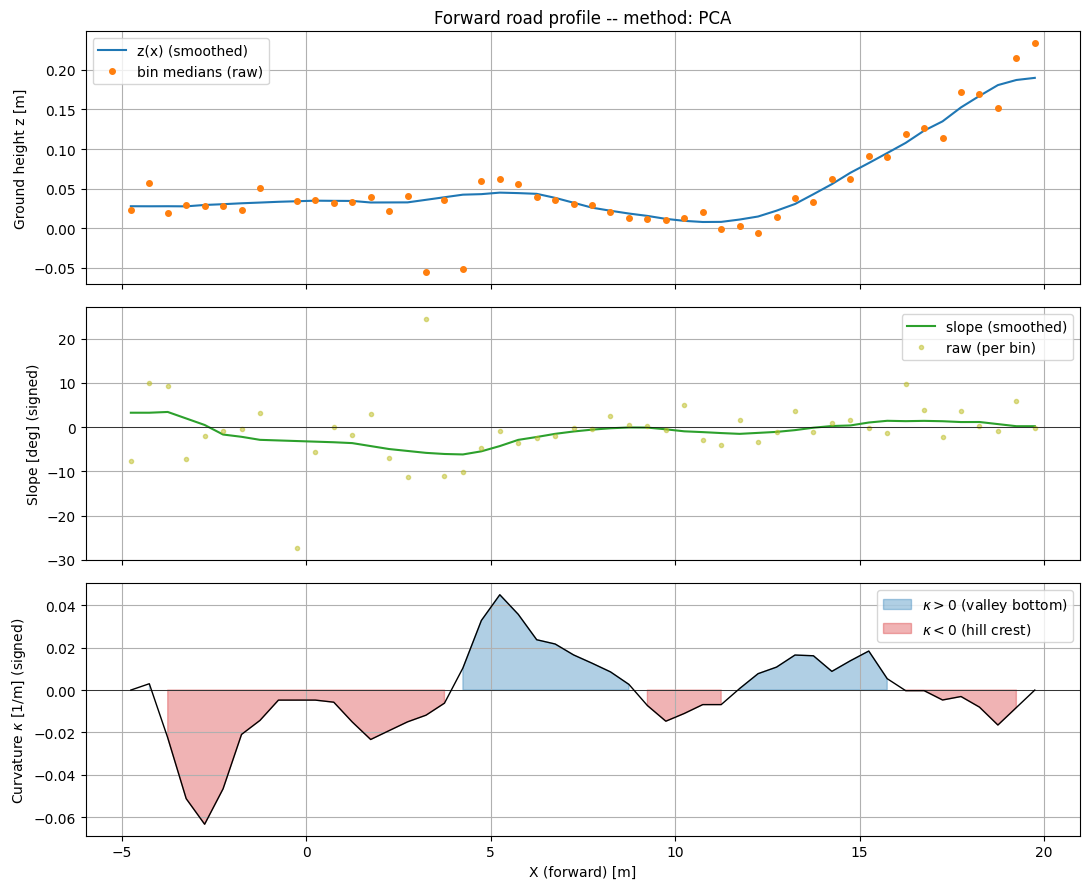

Method        : PCA
Mean slope    :  -1.21  deg
Mean kappa    : -0.0021  1/m
Max |kappa|   :  0.0634  1/m
Min radius    :    15.8  m
Concave-up    :  21 bins  (valley-shaped)
Concave-down  :  29 bins  (hill-shaped)

Method 2: RANSAC


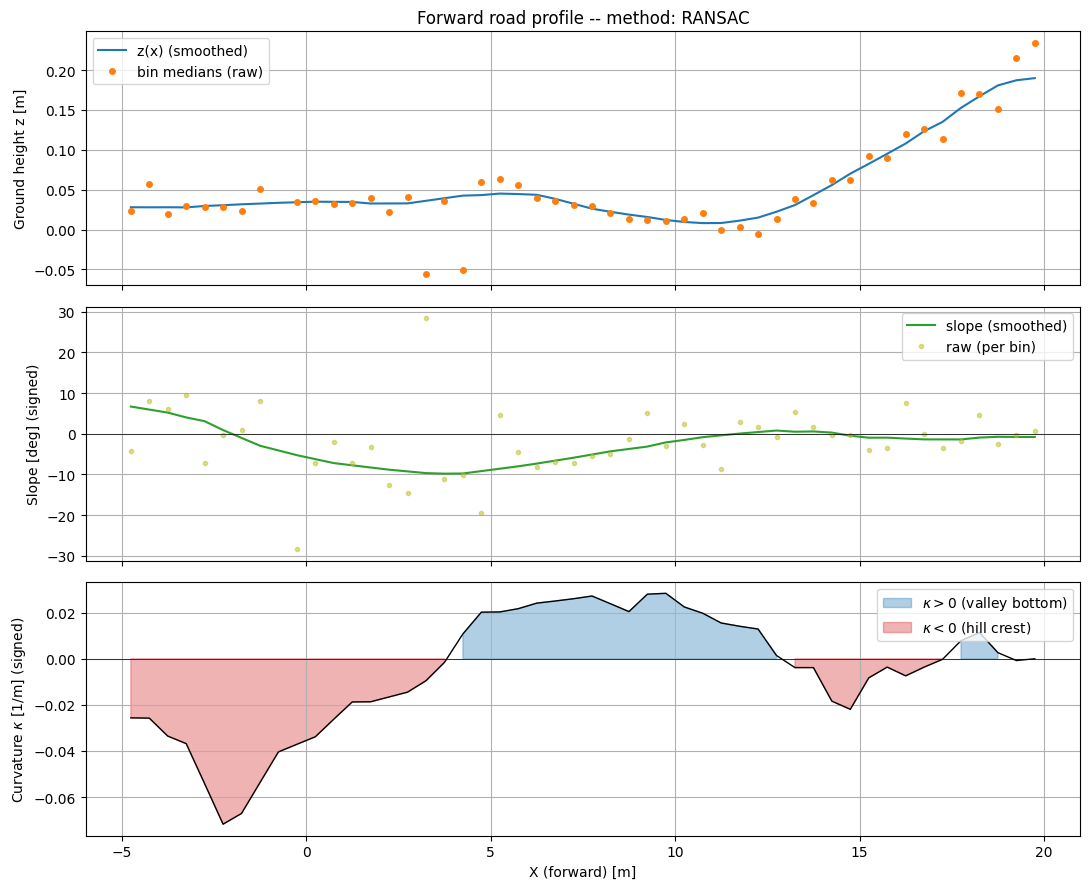

Method        : RANSAC
Mean slope    :  -2.81  deg
Mean kappa    : -0.0055  1/m
Max |kappa|   :  0.0718  1/m
Min radius    :    13.9  m
Concave-up    :  22 bins  (valley-shaped)
Concave-down  :  28 bins  (hill-shaped)

Method 3: Height-derivative


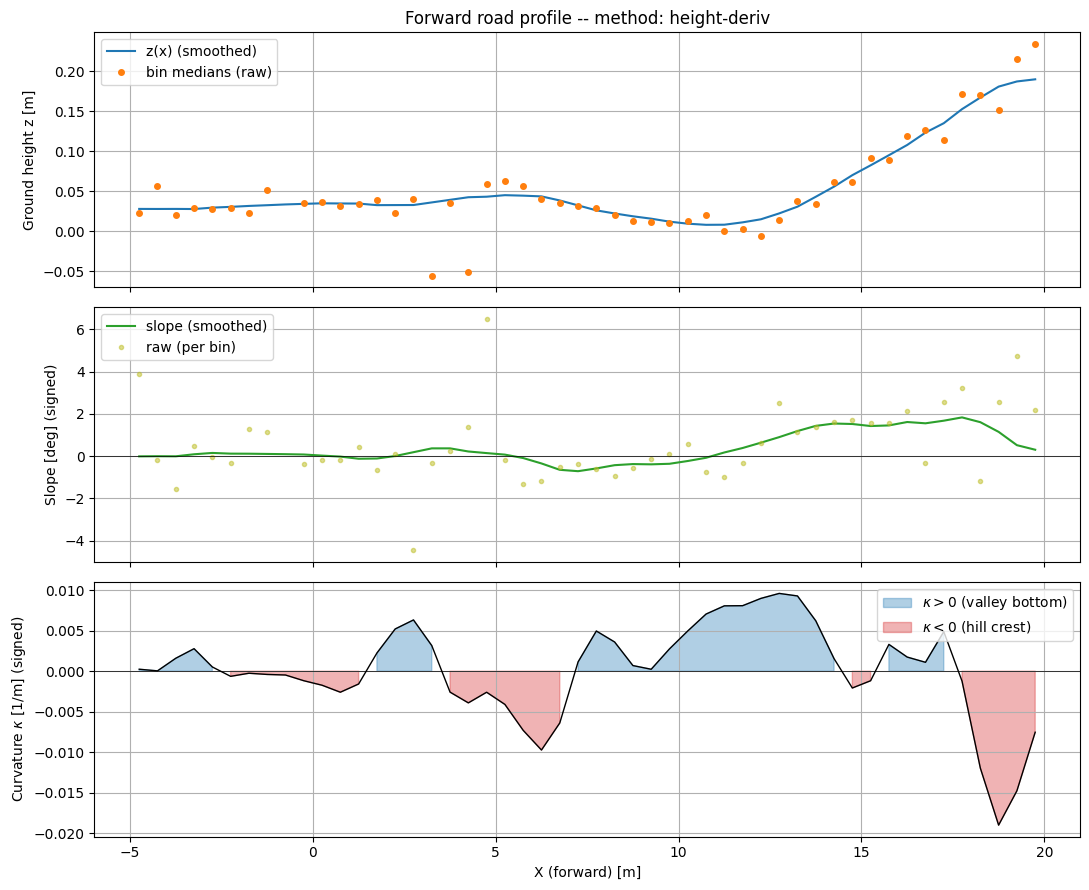

Method        : height-deriv
Mean slope    :  +0.37  deg
Mean kappa    : +0.0001  1/m
Max |kappa|   :  0.0190  1/m
Min radius    :    52.7  m
Concave-up    :  28 bins  (valley-shaped)
Concave-down  :  22 bins  (hill-shaped)


In [81]:
# Run all three methods on the same input
profile_pca = compute_road_profile_from_normals(
    ground, fit_normal=fit_pca_normal,    method_label="PCA")
profile_ran = compute_road_profile_from_normals(
    ground, fit_normal=fit_ransac_normal, method_label="RANSAC")
profile_hgt = compute_road_profile_from_heights(
    ground, method_label="height-deriv")

print("=" * 60); print("Method 1: PCA");           print("=" * 60)
plot_road_profile(profile_pca)
print("\n" + "=" * 60); print("Method 2: RANSAC");  print("=" * 60)
plot_road_profile(profile_ran)
print("\n" + "=" * 60); print("Method 3: Height-derivative"); print("=" * 60)
plot_road_profile(profile_hgt)



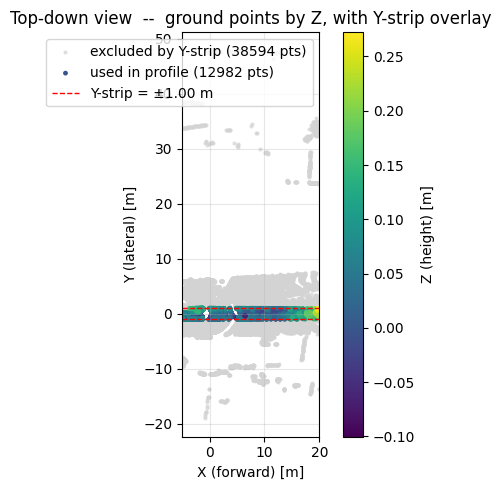

In [82]:
x_min, x_max = ROI_X_RANGE
y_strip      = abs(ROI_Y_RANGE[1])

in_x      = (ground[:, 0] >= x_min) & (ground[:, 0] <= x_max)
in_strip  = in_x & (np.abs(ground[:, 1]) <= y_strip)
in_excl   = in_x & ~in_strip

pts_used     = ground[in_strip]
pts_excluded = ground[in_excl]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# grey points outside the strip
if len(pts_excluded):
    ax.scatter(pts_excluded[:, 0], pts_excluded[:, 1],
               c="lightgrey", s=4, alpha=0.6,
               label=f"excluded by Y-strip ({len(pts_excluded)} pts)")

# colour-by-Z points inside the strip
if len(pts_used):
    sc = ax.scatter(pts_used[:, 0], pts_used[:, 1],
                    c=pts_used[:, 2], cmap="viridis", s=6,
                    label=f"used in profile ({len(pts_used)} pts)")
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Z (height) [m]")

# strip boundary
ax.axhline( y_strip, color="red", lw=1.0, ls="--",
            label=f"Y-strip = ±{y_strip:.2f} m")
ax.axhline(-y_strip, color="red", lw=1.0, ls="--")

ax.set_xlim(x_min, x_max)
ax.set_xlabel("X (forward) [m]")
ax.set_ylabel("Y (lateral) [m]")
ax.set_title("Top-down view  --  ground points by Z, with Y-strip overlay")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

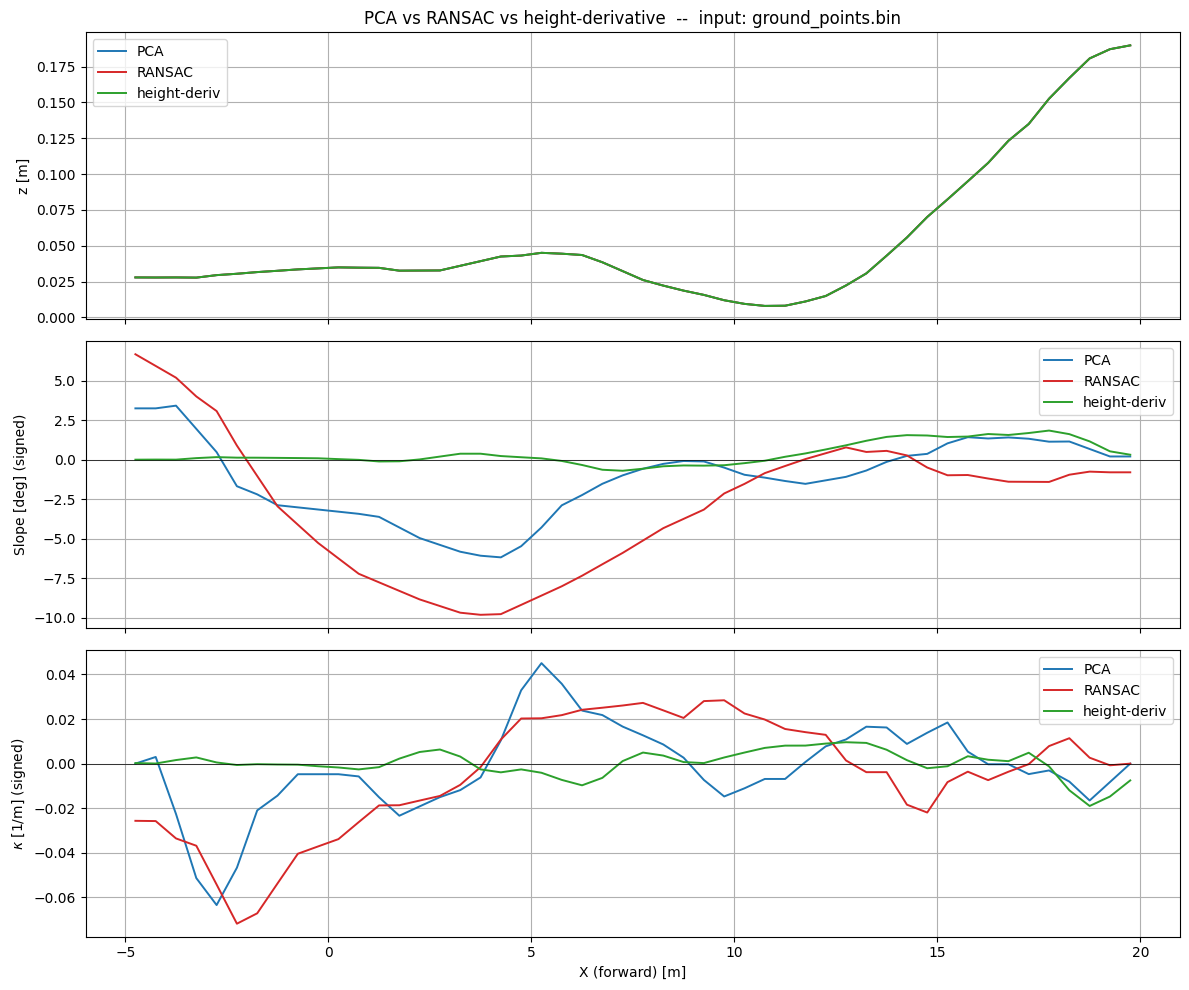

method           mean slope   mean kappa  max |kappa|   min radius
----------------------------------------------------------------
PCA                  -1.21      -0.0021       0.0634        15.8
RANSAC               -2.81      -0.0055       0.0718        13.9
height-deriv         +0.37      +0.0001       0.0190        52.7


In [83]:
def compare_methods(profiles, suptitle=""):
    """Overlay slope and signed kappa from up to 4 methods."""
    profiles = [p for p in profiles if p is not None]
    if not profiles:
        return

    colors = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
    fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # --- 1. height ---
    for p, c in zip(profiles, colors):
        ax[0].plot(p["x"], p["z"], "-", lw=1.4, color=c, label=p["method"])
    ax[0].set_ylabel("z [m]")
    ax[0].set_title(suptitle or "Method comparison -- forward road profile")
    ax[0].grid(True); ax[0].legend()

    # --- 2. slope ---
    for p, c in zip(profiles, colors):
        ax[1].plot(p["x"], p["slope_deg"], "-", lw=1.4, color=c,
                   label=p["method"])
    ax[1].axhline(0, color="k", lw=0.5)
    ax[1].set_ylabel("Slope [deg] (signed)")
    ax[1].grid(True); ax[1].legend()

    # --- 3. signed kappa ---
    for p, c in zip(profiles, colors):
        ax[2].plot(p["x"], p["kappa"], "-", lw=1.4, color=c,
                   label=p["method"])
    ax[2].axhline(0, color="k", lw=0.5)
    ax[2].set_xlabel("X (forward) [m]")
    ax[2].set_ylabel(r"$\kappa$ [1/m] (signed)")
    ax[2].grid(True); ax[2].legend()

    plt.tight_layout(); plt.show()

    # quick numeric table
    print(f"{'method':<14} {'mean slope':>12} {'mean kappa':>12} "
          f"{'max |kappa|':>12} {'min radius':>12}")
    print("-" * 64)
    for p in profiles:
        rmin = 1.0 / p["kappa_abs"].max() if p["kappa_abs"].max() > 1e-6 else float("inf")
        print(f"{p['method']:<14} "
              f"{p['slope_deg'].mean():>+11.2f} "
              f"{p['kappa'].mean():>+12.4f} "
              f"{p['kappa_abs'].max():>12.4f} "
              f"{rmin:>11.1f}")


compare_methods([profile_pca, profile_ran, profile_hgt],
                suptitle=f"PCA vs RANSAC vs height-derivative  --  input: {INPUT_BIN_NAME}")

## 5. 2-D Cartesian grid heatmap

The forward 1-D profile is the cleanest comparison, but the BEP supervisors
will probably also want to see *where* on the ground the methods diverge.
Below, the same three methods produce a **per-cell slope and curvature**
field on a Cartesian grid:

* **PCA / RANSAC.** Per cell, fit a plane and read slope from the normal.
  Curvature comes from the dimensionless $\sigma = \lambda_3/\sum\lambda_i$
  (PCA) or the equivalent residual ratio (RANSAC). This matches the v7 metric.
* **Height-derivative.** Per cell, take median $z$ over a smoothed grid, then
  apply finite differences across cells to get $\partial z/\partial x$,
  $\partial^2 z/\partial x^2$ and the corresponding signed forward curvature.

These three heatmaps live next to each other in `plot_grid_compare`. Where the
ground is genuinely curving in the +X direction, all three should light up.
Where one lights up and the others don't, that's a methodology story for the
report — usually a single noisy cell that PCA averaged over but height-derivative
chased.

In [86]:
def compute_grid_pca(ground_points,
                     cell_size=GRID_CELL_SIZE,
                     min_pts_per_cell=GRID_MIN_PTS_PER_CELL,
                     x_range=ROI_X_RANGE,
                     y_range=ROI_Y_RANGE):
    """Per-cell PCA plane. Curvature = lam3 / sum(lam_i) (Patchwork++ Eq. 3).

    Returns a dict keyed by cx, cy, slope_deg, curv (positive scalar).
    """
    x_edges = np.arange(x_range[0], x_range[1] + cell_size, cell_size)
    y_edges = np.arange(y_range[0], y_range[1] + cell_size, cell_size)
    ix = np.digitize(ground_points[:, 0], x_edges) - 1
    iy = np.digitize(ground_points[:, 1], y_edges) - 1
    valid = ((ix >= 0) & (ix < len(x_edges) - 1) &
             (iy >= 0) & (iy < len(y_edges) - 1))
    ix, iy = ix[valid], iy[valid]
    pts = ground_points[valid]
    z_axis = np.array([0.0, 0.0, 1.0])

    cxs, cys, slopes, curvs = [], [], [], []
    lin = ix * len(y_edges) + iy
    for lin_key in np.unique(lin):
        cell_pts = pts[lin == lin_key]
        if len(cell_pts) < min_pts_per_cell:
            continue
        cell_pts = cell_pts.astype(np.float64)
        c = cell_pts.mean(axis=0)
        cov = np.cov((cell_pts - c).T)
        w, V = np.linalg.eigh(cov)
        eigvals = w[::-1]
        n = V[:, 0]
        if n[2] < 0:
            n = -n
        slope_deg = np.degrees(np.arccos(np.clip(n @ z_axis, -1.0, 1.0)))
        curv = float(eigvals[2] / (eigvals.sum() + 1e-12))
        i_cell = lin_key // len(y_edges)
        j_cell = lin_key %  len(y_edges)
        cxs.append(0.5 * (x_edges[i_cell] + x_edges[i_cell + 1]))
        cys.append(0.5 * (y_edges[j_cell] + y_edges[j_cell + 1]))
        slopes.append(slope_deg); curvs.append(curv)

    return dict(method="PCA",
                cx=np.array(cxs), cy=np.array(cys),
                slope=np.array(slopes), curv=np.array(curvs))


def compute_grid_ransac(ground_points,
                        cell_size=GRID_CELL_SIZE,
                        min_pts_per_cell=GRID_MIN_PTS_PER_CELL,
                        x_range=ROI_X_RANGE,
                        y_range=ROI_Y_RANGE,
                        dist_thresh=RANSAC_DIST_THRESH,
                        n_iter=RANSAC_N_ITER):
    x_edges = np.arange(x_range[0], x_range[1] + cell_size, cell_size)
    y_edges = np.arange(y_range[0], y_range[1] + cell_size, cell_size)
    ix = np.digitize(ground_points[:, 0], x_edges) - 1
    iy = np.digitize(ground_points[:, 1], y_edges) - 1
    valid = ((ix >= 0) & (ix < len(x_edges) - 1) &
             (iy >= 0) & (iy < len(y_edges) - 1))
    ix, iy = ix[valid], iy[valid]
    pts = ground_points[valid]
    z_axis = np.array([0.0, 0.0, 1.0])

    cxs, cys, slopes, curvs = [], [], [], []
    lin = ix * len(y_edges) + iy
    for lin_key in np.unique(lin):
        cell_pts = pts[lin == lin_key].astype(np.float64)
        if len(cell_pts) < min_pts_per_cell:
            continue
        try:
            n = fit_ransac_normal(cell_pts,
                                  n_iter=n_iter,
                                  dist_thresh=dist_thresh,
                                  min_inliers=RANSAC_MIN_INLIERS)  # was min_pts_per_cell
        except RuntimeError:
            continue   # skip this cell, don't crash the whole grid

        slope_deg = np.degrees(np.arccos(np.clip(n @ z_axis, -1.0, 1.0)))

        c = cell_pts.mean(axis=0)
        d = cell_pts - c
        residuals = d @ n
        total_var = (d * d).sum()
        curv = float((residuals ** 2).sum() / (total_var + 1e-12))

        i_cell = lin_key // len(y_edges)
        j_cell = lin_key %  len(y_edges)
        cxs.append(0.5 * (x_edges[i_cell] + x_edges[i_cell + 1]))
        cys.append(0.5 * (y_edges[j_cell] + y_edges[j_cell + 1]))
        slopes.append(slope_deg)
        curvs.append(curv)

    return dict(method="RANSAC",
                cx=np.array(cxs), cy=np.array(cys),
                slope=np.array(slopes), curv=np.array(curvs))


def compute_grid_height_deriv(ground_points,
                              cell_size=GRID_CELL_SIZE,
                              min_pts_per_cell=GRID_MIN_PTS_PER_CELL,
                              x_range=ROI_X_RANGE,
                              y_range=ROI_Y_RANGE):
    """Per-cell median(z) array, then finite differences across cells.

    Slope = arctan(sqrt((dz/dx)^2 + (dz/dy)^2))   [deg]
    Curvature = signed forward kappa
              = (d2z/dx2) / (1 + (dz/dx)^2)^(3/2)  [1/m]
    """
    x_edges = np.arange(x_range[0], x_range[1] + cell_size, cell_size)
    y_edges = np.arange(y_range[0], y_range[1] + cell_size, cell_size)
    nx = len(x_edges) - 1
    ny = len(y_edges) - 1

    Z = np.full((nx, ny), np.nan)

    ix = np.digitize(ground_points[:, 0], x_edges) - 1
    iy = np.digitize(ground_points[:, 1], y_edges) - 1
    valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
    ix, iy = ix[valid], iy[valid]
    pts = ground_points[valid]

    lin = ix * ny + iy
    for lin_key in np.unique(lin):
        cell_pts = pts[lin == lin_key]
        if len(cell_pts) < min_pts_per_cell:
            continue
        i_cell = lin_key // ny
        j_cell = lin_key %  ny
        Z[i_cell, j_cell] = float(np.median(cell_pts[:, 2]))

    # fill NaNs by row-wise interpolation along x (where we have neighbours)
    for j in range(ny):
        col = Z[:, j]
        good = ~np.isnan(col)
        if good.sum() >= 2:
            Z[:, j] = np.interp(np.arange(nx),
                                np.arange(nx)[good], col[good])

    if np.isnan(Z).any():
        # any column with no good values stays NaN -- mask it out
        good_cells = ~np.isnan(Z)
    else:
        good_cells = np.ones_like(Z, dtype=bool)

    # finite differences (central, with reflective boundary handling)
    dz_dx = np.gradient(Z, cell_size, axis=0)
    dz_dy = np.gradient(Z, cell_size, axis=1)
    d2z_dx2 = np.gradient(dz_dx, cell_size, axis=0)

    slope_field = np.degrees(np.arctan(np.sqrt(dz_dx ** 2 + dz_dy ** 2)))
    kappa_field = d2z_dx2 / (1.0 + dz_dx ** 2) ** 1.5    # signed forward kappa

    cxs, cys, slopes, curvs = [], [], [], []
    for i in range(nx):
        for j in range(ny):
            if not good_cells[i, j]:
                continue
            cx = 0.5 * (x_edges[i] + x_edges[i + 1])
            cy = 0.5 * (y_edges[j] + y_edges[j + 1])
            cxs.append(cx); cys.append(cy)
            slopes.append(slope_field[i, j])
            curvs.append(kappa_field[i, j])

    return dict(method="height-deriv",
                cx=np.array(cxs), cy=np.array(cys),
                slope=np.array(slopes), curv=np.array(curvs))

PCA          : 249 cells  slope mean=7.84 deg  curv mean=0.0036
RANSAC       : 249 cells  slope mean=8.79 deg  curv mean=0.0047
height-deriv : 300 cells  slope mean=6.01 deg  curv mean=+0.0021  (signed, 1/m)


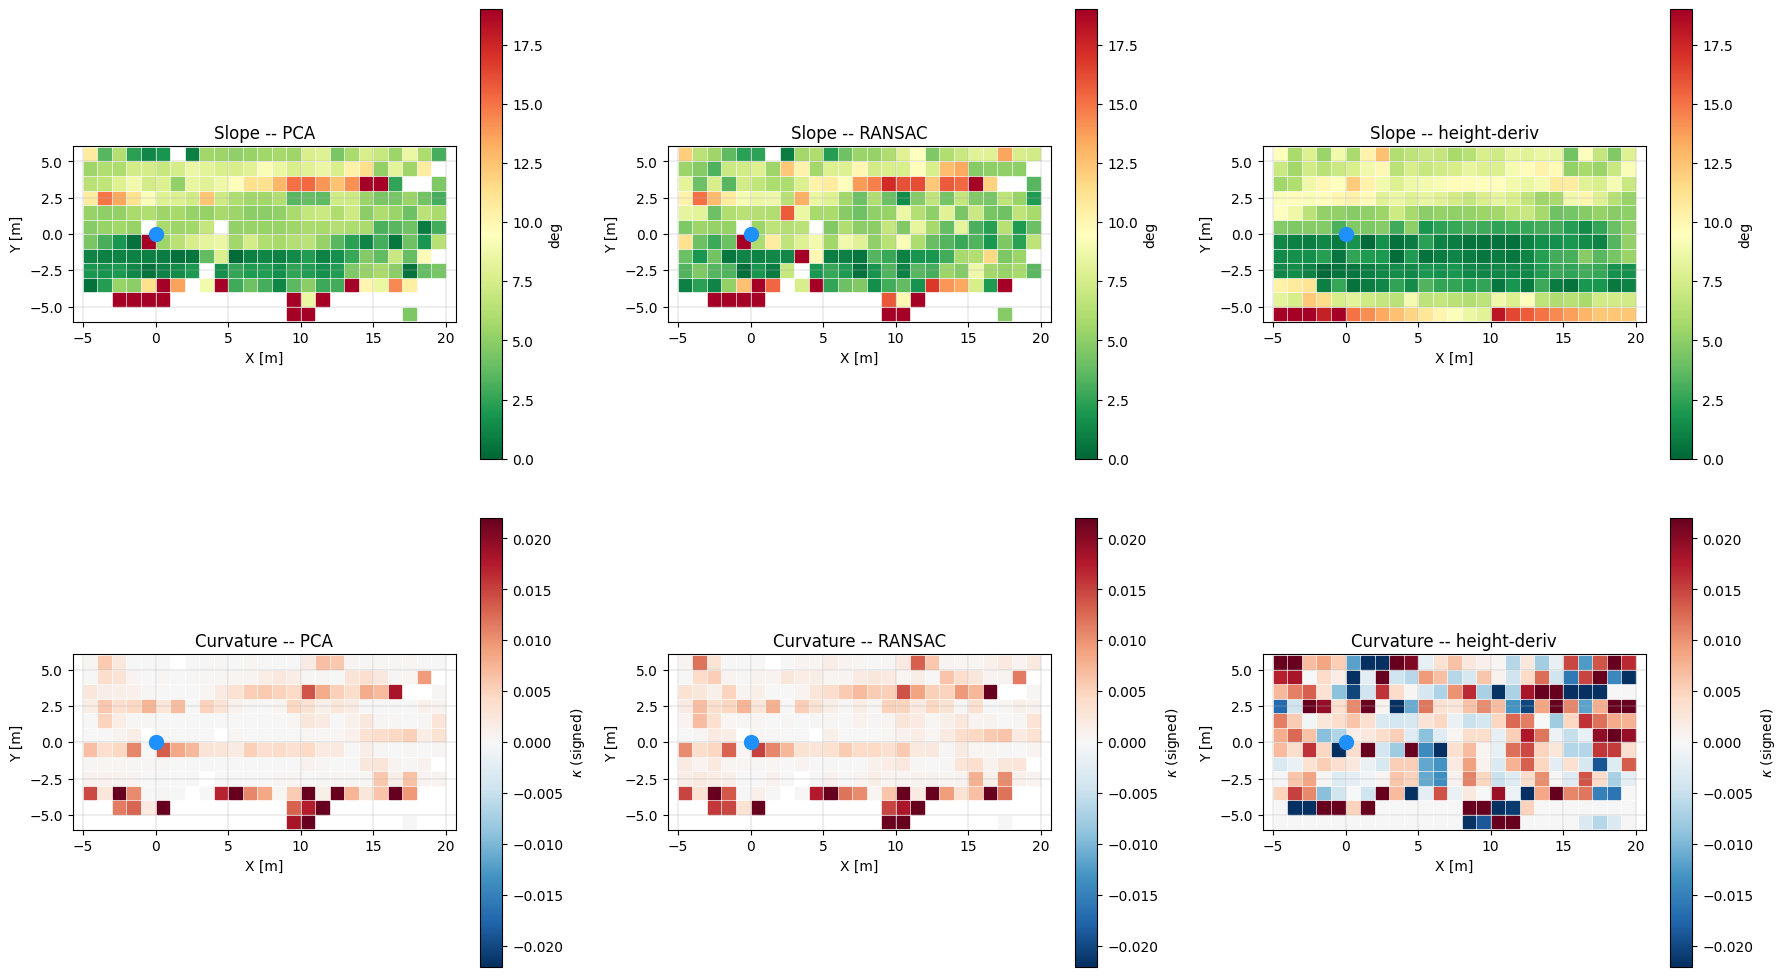

In [87]:
def plot_grid_compare(grids, cell_size=GRID_CELL_SIZE):
    """Side-by-side slope and curvature heatmaps for each method."""
    n = len(grids)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 11))
    if n == 1:
        axes = axes.reshape(2, 1)

    # consistent colour limits per row
    slope_max = max(np.percentile(g["slope"], 95) for g in grids if len(g["slope"]))
    curv_vals = np.concatenate([g["curv"] for g in grids if len(g["curv"])])
    cmin = float(np.percentile(curv_vals,  5))
    cmax = float(np.percentile(curv_vals, 95))

    # signed curvature: keep symmetric range when sensible
    if cmin < 0 and cmax > 0:
        cabs = max(abs(cmin), abs(cmax))
        cmin, cmax = -cabs, cabs
        cmap_c = "RdBu_r"
        clabel = r"$\kappa$ (signed)"
    else:
        cmap_c = "magma_r"
        clabel = "curvature metric"

    for k, g in enumerate(grids):
        ax_s = axes[0, k]
        ax_c = axes[1, k]
        if len(g["cx"]) == 0:
            ax_s.set_title(f"{g['method']}: no cells"); continue

        sc_s = ax_s.scatter(g["cx"], g["cy"], c=g["slope"], cmap="RdYlGn_r",
                            s=(cell_size * 9) ** 2, marker="s",
                            vmin=0, vmax=float(slope_max))
        ax_s.plot(0, 0, "o", color="dodgerblue", ms=10)
        ax_s.set_title(f"Slope -- {g['method']}")
        plt.colorbar(sc_s, ax=ax_s, label="deg", shrink=0.8)

        sc_c = ax_c.scatter(g["cx"], g["cy"], c=g["curv"], cmap=cmap_c,
                            s=(cell_size * 9) ** 2, marker="s",
                            vmin=cmin, vmax=cmax)
        ax_c.plot(0, 0, "o", color="dodgerblue", ms=10)
        ax_c.set_title(f"Curvature -- {g['method']}")
        plt.colorbar(sc_c, ax=ax_c, label=clabel, shrink=0.8)

    for ax in axes.ravel():
        ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
        ax.set_aspect("equal"); ax.grid(True, lw=0.3)

    plt.tight_layout(); plt.show()


# Run all three on the 2-D grid
grid_pca = compute_grid_pca(ground,y_range=GRID_Y_RANGE)
grid_ran = compute_grid_ransac(ground,y_range=GRID_Y_RANGE)
grid_hgt = compute_grid_height_deriv(ground,y_range=GRID_Y_RANGE)

print(f"PCA          : {len(grid_pca['cx']):3d} cells  "
      f"slope mean={grid_pca['slope'].mean():.2f} deg  "
      f"curv mean={grid_pca['curv'].mean():.4f}")
print(f"RANSAC       : {len(grid_ran['cx']):3d} cells  "
      f"slope mean={grid_ran['slope'].mean():.2f} deg  "
      f"curv mean={grid_ran['curv'].mean():.4f}")
print(f"height-deriv : {len(grid_hgt['cx']):3d} cells  "
      f"slope mean={grid_hgt['slope'].mean():.2f} deg  "
      f"curv mean={grid_hgt['curv'].mean():+.4f}  (signed, 1/m)")

plot_grid_compare([grid_pca, grid_ran, grid_hgt])

## What this notebook gives you for the BEP report

* **One input file → three method outputs** with no other variables changing.
  That's exactly the methodology the BEP brief asks for: *"isolating one
  variable at a time is essential for a defensible comparison"*.
* **Same plots, same scales** for all three methods. Direct overlay in `compare_methods`.
* **Two complementary views** — the forward 1-D profile (clean, signed,
  physical units of m⁻¹) and the 2-D heatmap (spatial, shows where methods agree
  and disagree).

### A natural ablation matrix

Re-run **Notebook 1** with a different filter (or use Karel's RANSAC pipeline as
a third filter) → save to a different `.bin` → change `INPUT_BIN_NAME` here →
get a new column in the table:

| Filter \ Method | PCA | RANSAC | height-deriv |
|---|---|---|---|
| Patchwork++              | (run) | (run) | (run) |
| Patchwork++ + GLE filter | (run) | (run) | (run) |
| RANSAC ground filter     | (run) | (run) | (run) |

Each cell of that 3 × 3 takes ~30 seconds to run. The table itself is
defensible methodology — and a great defence-presentation slide.

### Suggested defence-prep experiments

1. **Flat-floor sanity check.** Take a frame you *know* is flat (empty parking
   lot). All three methods should report $\kappa \approx 0$ in physical units.
   Whatever they report is your **noise floor**.
2. **IMU correlation.** Cross-correlate `slope_deg(t)` from each method
   against IMU pitch. Best method = highest correlation, smallest lag.
3. **Bin-size sweep.** Vary `PROFILE_BIN_SIZE` over $\{0.25, 0.5, 1.0, 2.0\}$ m
   and plot how each method's $\max|\kappa|$ changes. Shows the
   spatial-scale trade-off — small bins = noisy, big bins = blur out features.
4. **Smoothing-window sweep.** Same idea but for `PROFILE_SMOOTH_WINDOW`.
   Particularly informative for height-derivative, which amplifies noise the
   most (one extra differentiation than the plane-fit methods).